In [1]:
# Setup and load model
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ast import literal_eval

current = os.getcwd()
parent = os.path.dirname(current)
sys.path.append(parent)

converters = {
    "Word": str, 
    "Phonemes": literal_eval, 
    "No_Stress": literal_eval,
}

from swp.utils.setup import seed_everything, set_device
from swp.utils.models import get_model
from swp.utils.embeddings import create_embeddings_LSTM_hook
from swp.datasets.phonemes import get_phoneme_to_id

seed_everything(42)
device = set_device()

# Load model
model_name = "Ua_LSTM_h128_l1_v42_d0.0_t0.0_s1"
weights_path = "weights/1024_75.pth"
hidden_size = 128

model = get_model(model_name)
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

# Get phoneme mappings
phoneme_to_id = get_phoneme_to_id()
id_to_phoneme = {v: k for k, v in phoneme_to_id.items()}

Using MPS device


In [3]:
model

Unimodel(
  (encoder): EncoderLSTM(
    (embedding): Embedding(42, 128)
    (dropout): Dropout(p=0.0, inplace=False)
    (recurrent): LSTM(128, 128, batch_first=True)
  )
  (decoder): DecoderLSTM(
    (embedding): Embedding(42, 128)
    (dropout): Dropout(p=0.0, inplace=False)
    (recurrent): LSTM(128, 128, batch_first=True)
  )
)

# plot hidden state


In [4]:

#  Function to get hidden states after each phoneme
def get_hidden_states_per_phoneme(model, phonemes: list, device, add_eos: bool = True):
    """
    Extract hidden states after EACH phoneme in the input sequence.
    
    Args:
        model: The trained encoder-decoder model
        phonemes: List of phoneme strings, e.g., ["K", "AE", "T"]
        device: torch device
        add_eos: Whether to add <EOS> token
    
    Returns:
        hidden_states: np.ndarray of shape (seq_len, hidden_size)
                       Hidden state after each phoneme
        labels: List of phoneme labels for x-axis
    """
    # Clear buffer and create hook
    buffer = {"Hidden": [], "Cell": [], "Out": []}
    hook = create_embeddings_LSTM_hook(buffer, is_batched=False, store_out=False, num_layers=1)
    hook_handle = model.encoder.recurrent.register_forward_hook(hook)
    
    # Tokenize phonemes
    tokens = [phoneme_to_id[p] for p in phonemes]
    if add_eos:
        tokens.append(phoneme_to_id["<EOS>"])
        labels = phonemes + ["<EOS>"]
    else:
        labels = phonemes.copy()
    
    # Create input tensor [batch=1, seq_len]
    inp = torch.tensor([tokens], device=device)
    seq_len = len(tokens)
    
    # Forward pass through encoder
    with torch.no_grad():
        model.encoder(inp)
        
    
    print(buffer["Out"].shape, buffer["Hidden"].shape, buffer["Cell"].shape)
    # Extract hidden states from "Out" 
    # buffer["Out"][0] has shape [batch, MAX_PAD, hidden_size]
    # # We take the first batch item and only the actual sequence length
    # hidden_states = buffer["Out"][0][0, :seq_len, :]  # [seq_len, hidden_size]
    
    # # Also get final states for comparison
    # final_hidden = buffer["Hidden"][0][0]  # [hidden_size]
    # cell_states = buffer["Cell"][0][:seq_len, :]  
    
    # # Clean up hook
    # hook_handle.remove()
    
    # return out, labels, h, c
# Cell 3: Function to plot hidden states
def plot_hidden_states(hidden_states, labels, title="Hidden States After Each Phoneme"):
    """
    Plot hidden states as a heatmap.
    
    Args:
        hidden_states: np.ndarray of shape (seq_len, hidden_size)
        labels: List of phoneme labels for x-axis
        title: Plot title
    """
    fig, ax = plt.subplots(figsize=(max(8, len(labels)*1.2), 5))
    
    im = ax.imshow(hidden_states.T, aspect="auto", interpolation="nearest", cmap="viridis")
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=12)
    ax.set_xlabel("Phoneme (input position)", fontsize=12)
    ax.set_ylabel("Hidden Unit", fontsize=12)
    ax.set_title(title, fontsize=14)
    
    plt.colorbar(im, ax=ax, label="Activation")
    plt.tight_layout()
    
    return fig, ax


In [5]:
get_hidden_states_per_phoneme(
    model, phonemes, device, add_eos=True
)

NameError: name 'phonemes' is not defined

In [ ]:
# Example word: PAPA = ["P", "AH", "P", "AH"]
phonemes = ["P", "AH", "P", "AH"]

hidden_states, labels, final_h, final_c = get_hidden_states_per_phoneme(
    model, phonemes, device, add_eos=True
)

print(f"Word phonemes: {phonemes}")
print(f"Labels : {labels}")
print(f"out shape: {hidden_states.shape}")  # (4, 128) for 3 phonemes + EOS
print(f"c shape: {final_c.shape}") 
print(f"h shape: {final_h.shape}")         # (128,)

# # # Verify: the last row of hidden_states should equal final_hidden
# # print(f"\nVerification - Last hidden state equals final hidden: {np.allclose(hidden_states[-1], final_h)}")

# #Convert final_c to numpy
# final_c = final_c.cpu().numpy()
# # Plot
# fig, ax = plot_hidden_states(final_c, labels, title=f"Hidden States: {' → '.join(phonemes)}")
# plt.show()

ValueError: too many values to unpack (expected 3)

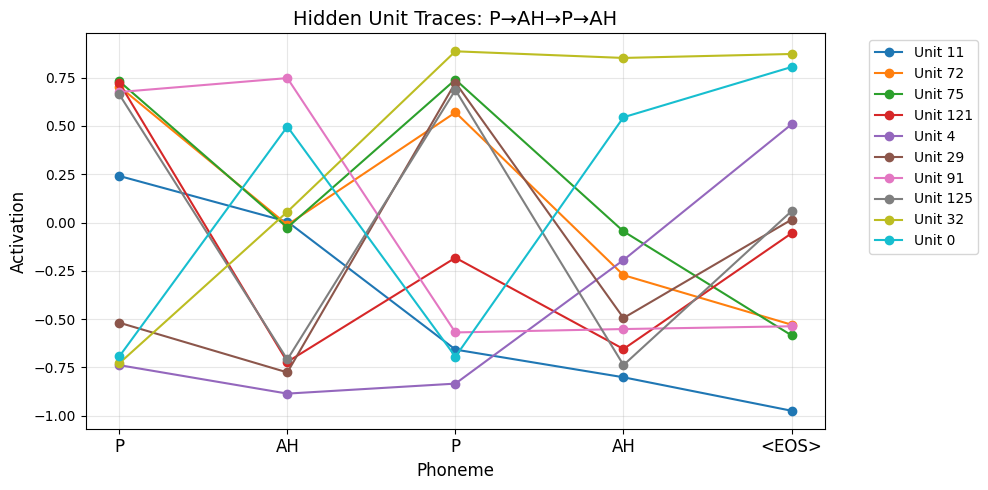

In [ ]:
# Cell 6: Plot evolution of specific hidden units over phonemes
def plot_hidden_unit_traces(hidden_states, labels, units_to_plot=None, title="Hidden Unit Activations"):
    """
    Plot how specific hidden units change across phonemes (line plot).
    """
    if units_to_plot is None:
        # Select units with high variance (most interesting)
        variances = np.var(hidden_states, axis=0)
        units_to_plot = np.argsort(variances)[-10:]  # Top 10 most variable units
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    for unit in units_to_plot:
        ax.plot(range(len(labels)), hidden_states[:, unit], marker='o', label=f'Unit {unit}')
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=12)
    ax.set_xlabel("Phoneme", fontsize=12)
    ax.set_ylabel("Activation", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, ax

# Example usage
phonemes = ["P", "AH", "P", "AH"]  # "papa" - interesting for repeated phonemes
hidden_states, labels, _, _ = get_hidden_states_per_phoneme(model, phonemes, device)

fig, ax = plot_hidden_unit_traces(hidden_states, labels, title=f'Hidden Unit Traces: {"→".join(phonemes)}')
plt.show()

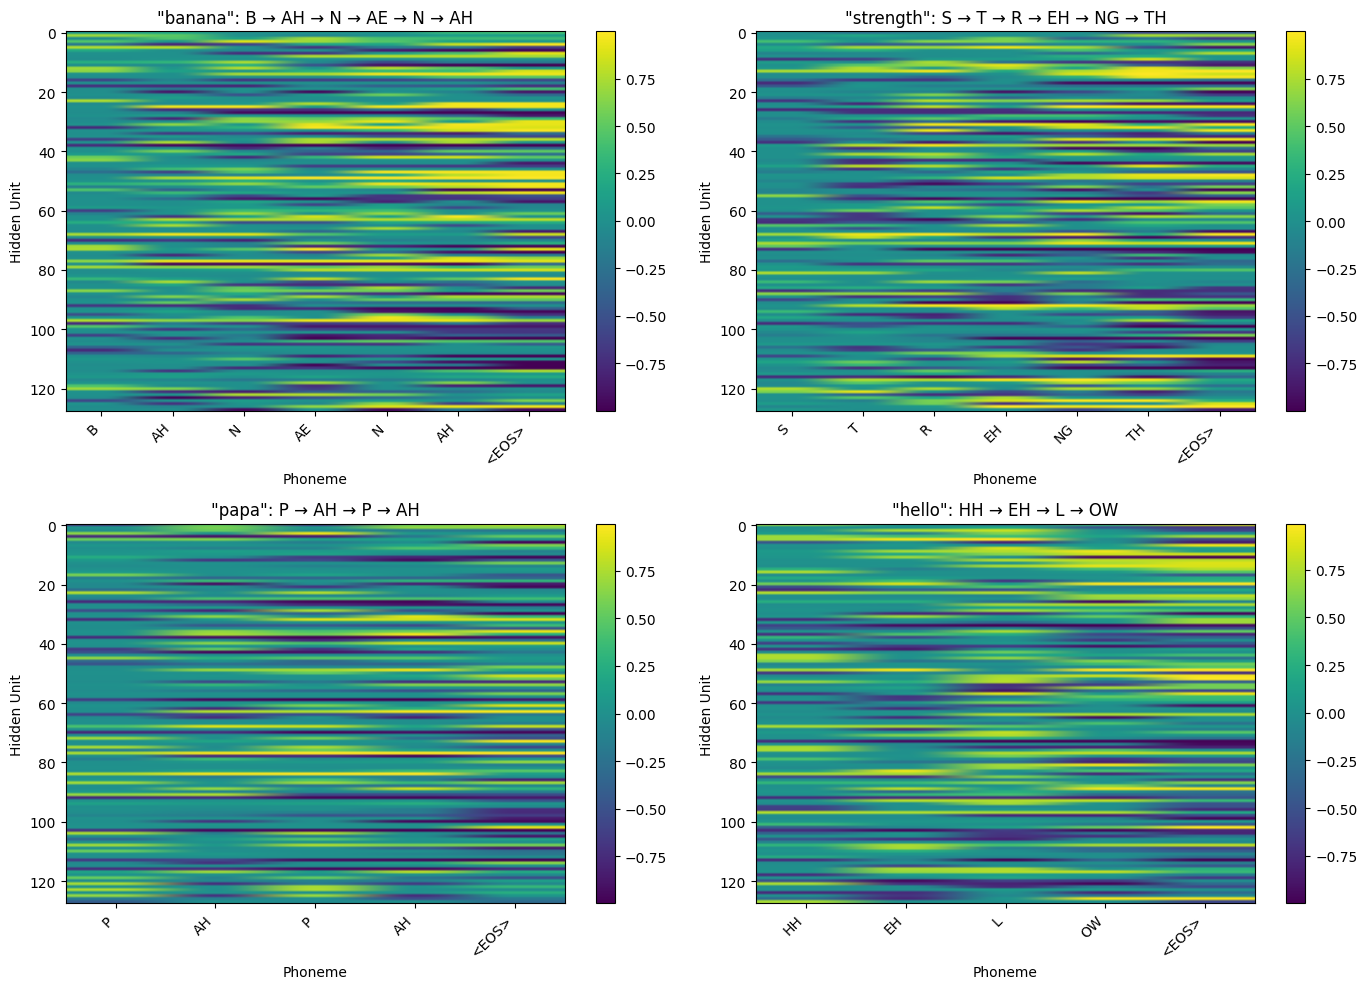

In [ ]:
# Cell 5: More examples
example_words = [
    (["B", "AH", "N", "AE", "N", "AH"], "banana"),
    (["S", "T", "R", "EH", "NG", "TH"], "strength"),
    (["P", "AH", "P", "AH"], "papa"),
    (["HH", "EH", "L", "OW"], "hello"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (phonemes, word) in zip(axes, example_words):
    hidden_states, labels, _, _ = get_hidden_states_per_phoneme(model, phonemes, device)
    
    im = ax.imshow(hidden_states.T, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel("Phoneme")
    ax.set_ylabel("Hidden Unit")
    ax.set_title(f'"{word}": {" → ".join(phonemes)}')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

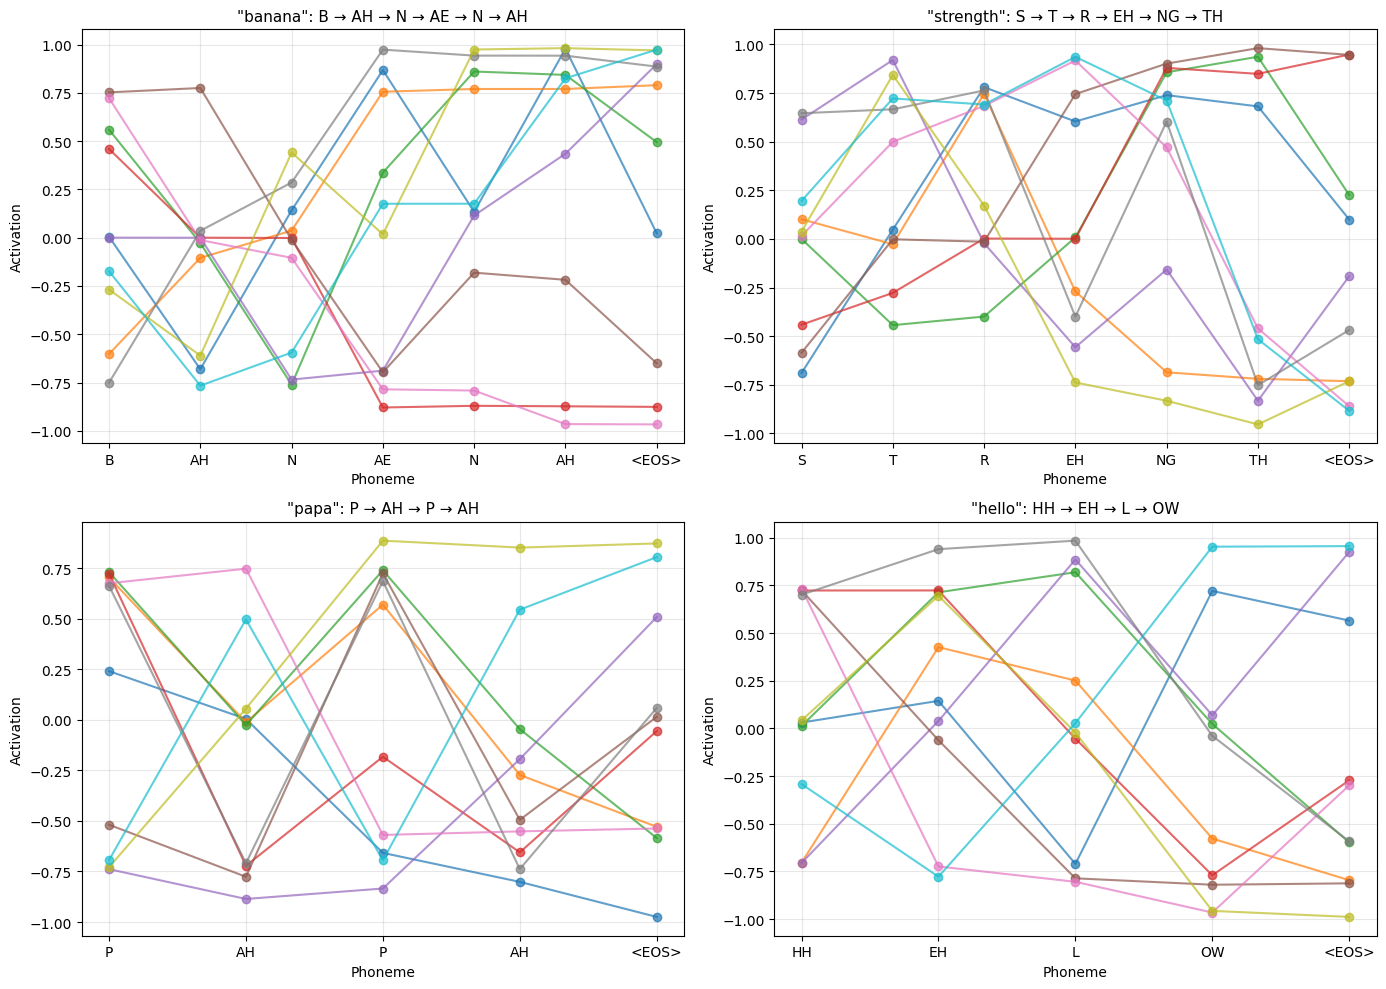

In [ ]:
example_words = [
    (["B", "AH", "N", "AE", "N", "AH"], "banana"),
    (["S", "T", "R", "EH", "NG", "TH"], "strength"),
    (["P", "AH", "P", "AH"], "papa"),
    (["HH", "EH", "L", "OW"], "hello"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (phonemes, word) in zip(axes, example_words):
    hidden_states, labels, _, _ = get_hidden_states_per_phoneme(model, phonemes, device)
    
    # Select units with high variance (most interesting)
    variances = np.var(hidden_states, axis=0)
    units_to_plot = np.argsort(variances)[-10:]  # Top 10 most variable units
    
    # Plot traces on this subplot
    for unit in units_to_plot:
        ax.plot(range(len(labels)), hidden_states[:, unit], marker='o', alpha=0.7)
    
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Phoneme", fontsize=10)
    ax.set_ylabel("Activation", fontsize=10)
    ax.set_title(f'"{word}": {" → ".join(phonemes)}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

#sample randmply from wfe_df one example for each Condition column
wfe_df = pd.read_csv("datasets/wfe.csv", converters=converters)
wfe_test = wfe_df.groupby('Condition').apply(lambda x: x.sample(1, random_state=42)).reset_index(drop=True)
wfe_test

,Unnamed: 0,Word,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Phonemes,No_Stress,Part of Speech,Vowel Count,Consonant Count
0,216,havivited,pseudo,long,complex,NaN,9,NaN,"[HH, AE1, V, AH0, V, EY2, T, IH0, D]","[HH, AE, V, AH, V, EY, T, IH, D]",NaN,4,5
1,383,lastomen,pseudo,long,simple,NaN,8,NaN,"[L, AE1, S, T, AH0, M, AH0, N]","[L, AE, S, T, AH, M, AH, N]",NaN,3,5
2,116,mullboy,pseudo,short,complex,NaN,5,NaN,"[M, AH1, L, B, OY2]","[M, AH, L, B, OY]",NaN,2,3
3,316,addrol,pseudo,short,simple,NaN,5,NaN,"[AE1, D, R, AH0, L]","[AE, D, R, AH, L]",NaN,2,3
4,83,integrity,real,long,complex,1.660000e-05,9,4.22,"[IH0, N, T, EH1, G, R, AH0, T, IY0]","[IH, N, T, EH, G, R, AH, T, IY]",NOUN,4,5
5,183,faithfully,real,long,complex,1.860000e-06,7,3.27,"[F, EY1, TH, F, AH0, L, IY0]","[F, EY, TH, F, AH, L, IY]",ADV,3,4
6,283,complete,real,long,simple,1.260000e-04,7,5.10,"[K, AH0, M, P, L, IY1, T]","[K, AH, M, P, L, IY, T]",VERB,2,5
7,383,avocado,real,long,simple,2.820000e-06,7,3.45,"[AE2, V, AH0, K, AA1, D, OW0]","[AE, V, AH, K, AA, D, OW]",NOUN,4,3
8,483,lottery,real,short,complex,1.000000e-05,5,4.00,"[L, AA1, T, ER0, IY0]","[L, AA, T, ER, IY]",NOUN,3,2
9,583,beggar,real,short,complex,1.480000e-06,4,3.17,"[B, EH1, G, ER0]","[B, EH, G, ER]",NOUN,2,2


# onion Rep Intervention

- get the phoneme embeddings (input)
    - it should not be the same model 
- get last hidden state hl from encoder model. for each example
- train onion intervention to get the scaling parameters
    - get the hl of encoder for input
    - replace token using phoneme embedding and scale (intervene on hl)
    - run though decoder to get output
    - cross entropy for loss (output, input with replaced token)
- data
    - first try with wfe.csv 
    - different for real vs. sudo
    - generate data for training
    - hyper parameters
    - number of examples, itter, epochs
   

questions to be answered
- how effective intervention is
- is there a significant difference between sudo and real words?
other conditions?

error analysis
- position 
- vowel vs. constonant

- other phonemes (dipthong, phonological features,...)




In [6]:
# ONION INTERVENTION MODULE

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Constants
PAD_ID = phoneme_to_id["<PAD>"]
EOS_ID = phoneme_to_id["<EOS>"]
SOS_ID = phoneme_to_id["<SOS>"]


class OnionIntervention(nn.Module):
    """
    Onion Representation Intervention Module.
    
    Modifies hidden state: h_new = h + (embed(new) - embed(old)) * scale
    where scale = g * (gamma^pos) + pos * lin + b
    
    Uses normal position (0 = first phoneme, increasing toward end).
    """
    def __init__(self, hidden_size: int, vocab_size: int, max_seq_len: int = 20,
                 pretrained_embedding: nn.Embedding = None):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Embedding 
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        if pretrained_embedding is not None:
            self.embedding.weight.data.copy_(pretrained_embedding.weight.data)
        
        # Learnable scaling parameters
        self.gamma = nn.Parameter(torch.ones(hidden_size) * 0.9)  # Decay factor
        self.lin = nn.Parameter(torch.zeros(hidden_size))          # Linear term
        self.g = nn.Parameter(torch.ones(hidden_size))             # Scale
        self.b = nn.Parameter(torch.zeros(hidden_size))            # Bias
    
    def forward(self, h, c, old_token, new_token, position):
        """
        Args:
            h: [batch, hidden_size] - final hidden state
            c: [batch, hidden_size] - final cell state
            old_token: [batch] - original token ID
            new_token: [batch] - replacement token ID
            position: [batch] - position from START (0 = first phoneme)
        """
        # Position-dependent scale
        pos = position[:, None].float()
        
        scale = self.g * (self.gamma.pow(pos)) + pos * self.lin + self.b
        
        # Embedding difference
        x = self.embedding(old_token).tanh()
        y = self.embedding(new_token).tanh()
        
        return h, c +(y - x) * scale #
    
    def get_scale(self, pos: int):
        """Get scale vector at position (for visualization)."""
        p = torch.tensor([[pos]], device=self.g.device, dtype=torch.float)
        return self.g * (self.gamma.pow(p)) + p * self.lin + self.b
    
    def scale_parameters(self):
        """Return scale parameters for analysis."""
        return {
            "gamma": self.gamma.detach().cpu().numpy(),
            "lin": self.lin.detach().cpu().numpy(),
            "g": self.g.detach().cpu().numpy(),
            "b": self.b.detach().cpu().numpy(),
        }


print(f"Model: {type(model.encoder).__name__}, hidden={model.encoder.hidden_size}, vocab={model.encoder.vocab_size}")

Model: EncoderLSTM, hidden=128, vocab=42


In [7]:


def get_encoder_hidden(model, input_ids, device):
    """Get final hidden state from encoder LSTM."""
    with torch.no_grad():
        (h, c) = model.encoder(input_ids.to(device))
        return h[-1] , c[-1]  # Last layer: [batch, hidden_size]

    


def decode_with_hidden(model, h,c, target, device):
    """Decode with given hidden state, returns logits."""
    h, c = h.unsqueeze(0), c.unsqueeze(0)  # [1, batch, hidden]
    batch_size, max_len = target.shape
    
    outputs = []
    hidden = (h, c) # LSTM needs (h, c)
    inp = torch.full((batch_size, 1), model.start_token_id, device=device, dtype=torch.long)
    
    for t in range(max_len):
        embedded = model.decoder.dropout(model.decoder.embedding(inp))
        out, hidden = model.decoder.recurrent(embedded, hidden)
        logits = out @ model.decoder.embedding.weight.T
        outputs.append(logits)
        inp = target[:, t:t+1]  # Teacher forcing?
    
    return torch.cat(outputs, dim=1)


def run_intervention_step(model, intervention, batch, device, pad_id):
    """
    Run a single intervention step. Returns loss, preds, targets, seq_lens.
    """
    input_ids = batch["input"].to(device)
    target_ids = batch["target"].to(device)
    old_token = batch["old_token"].to(device)
    new_token = batch["new_token"].to(device)
    position = batch["position"].to(device)
    seq_len = batch["seq_len"]

    # get hidden states
    h, c = get_encoder_hidden(model, input_ids, device)
    # get modified hidden states
    h_mod, c_mod = intervention(h, c, old_token, new_token, position)


    logits = decode_with_hidden(model, h_mod, c_mod, target_ids, device)

   
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        target_ids.view(-1),
        ignore_index=pad_id,
    )
    
    preds = logits.argmax(dim=-1)
    return loss, preds, target_ids, seq_len



In [ ]:
############ QUESTION ##########
'''
need both h and c
should we modify both h and c in the intervention module?
use c without change?
should we train probe for h and seperatly or use one for both?
'''



'\nneed both h and c\nshould we modify both h and c in the intervention module?\nuse c without change?\nshould we train probe for h and seperatly or use one for both?\n'

In [8]:

def compute_accuracies(preds, targets, seq_lens, pad_id):
    """
    fraction of predictions equal to target 
    """
    batch_size = preds.shape[0]
    seq_correct = 0
    for i in range(batch_size):
        sl = seq_lens[i].item()
        if torch.equal(preds[i, :sl], targets[i, :sl]):
            seq_correct += 1
    seq_acc = seq_correct / batch_size
    
    return  seq_acc


def train_epoch(model, intervention, loader, optimizer, device, pad_id):
    """Train for one epoch."""
    intervention.train()
    model.eval()
    
    total_loss, total_seq_acc, n_batches = 0, 0, 0
    
    for batch in loader:
        optimizer.zero_grad()
        loss, preds, targets, seq_lens = run_intervention_step(model, intervention, batch, device, pad_id)
        loss.backward()
        optimizer.step()
        
        seq_acc = compute_accuracies(preds, targets, seq_lens, pad_id)
        total_loss += loss.item()
        total_seq_acc += seq_acc
        n_batches += 1
    
    return total_loss / n_batches, total_seq_acc / n_batches


@torch.no_grad()
def evaluate(model, intervention, loader, device, pad_id):
    """Evaluate and return loss, seq_acc."""
    intervention.eval()
    model.eval()
    
    total_loss, total_seq_acc, n_batches = 0, 0, 0
    
    for batch in loader:
        loss, preds, targets, seq_lens = run_intervention_step(model, intervention, batch, device, pad_id)
        seq_acc = compute_accuracies(preds, targets, seq_lens, pad_id)
        
        total_loss += loss.item()
        total_seq_acc += seq_acc
        n_batches += 1
    
    return total_loss / n_batches, total_seq_acc / n_batches


@torch.no_grad()
def evaluate_with_predictions(model, intervention, loader, device, pad_id, id_to_phoneme):
    """
    Evaluate and return detailed predictions DataFrame.
    """
    intervention.eval()
    model.eval()
    
    records = []
    for batch in loader:
        loss, preds, targets, seq_lens = run_intervention_step(model, intervention, batch, device, pad_id)
        
        batch_size = preds.shape[0]
        for i in range(batch_size):
            sl = seq_lens[i].item()
            pred_ids = preds[i, :sl].cpu().tolist()
            target_ids = targets[i, :sl].cpu().tolist()
            input_ids = batch["input"][i, :sl].tolist()
            
            pred_phonemes = [id_to_phoneme[p] for p in pred_ids]
            target_phonemes = [id_to_phoneme[t] for t in target_ids]
            input_phonemes = [id_to_phoneme[t] for t in input_ids]
            
            seq_correct = pred_ids == target_ids
            token_acc = sum(p == t for p, t in zip(pred_ids, target_ids)) / sl
            
            records.append({
                "input": " ".join(input_phonemes),
                "target": " ".join(target_phonemes),
                "prediction": " ".join(pred_phonemes),
                "position": batch["position"][i].item(),
                "old_phoneme": id_to_phoneme[batch["old_token"][i].item()],
                "new_phoneme": id_to_phoneme[batch["new_token"][i].item()],
                "seq_len": sl,
                "match": seq_correct,
                "token_acc": token_acc,
            })
    
    return pd.DataFrame(records)




In [ ]:


class InterventionDataset(Dataset):
    """Dataset for training the intervention model."""
    
    def __init__(self, phoneme_sequences: list, vocab_size: int, pad_id: int, 
                 eos_id: int, start_id: int, max_len: int = 20):
        self.sequences = phoneme_sequences
        self.vocab_size = vocab_size
        self.pad_id = pad_id
        self.eos_id = eos_id
        self.start_id = start_id
        self.max_len = max_len
        self.special_tokens = {pad_id, eos_id, start_id}
        self.test_run = False  # Set to True for testing intervention (no change)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx].copy()
        
        # Add EOS if not present
        if seq[-1] != self.eos_id:
            seq.append(self.eos_id)
        seq_len = len(seq)
        
        # Random position to replace (exclude EOS)
        replace_pos = np.random.randint(0, seq_len - 1)
        old_token = seq[replace_pos]
        
        if not self.test_run:
            # Random new token (different from old, not special)
            valid_tokens = [t for t in range(self.vocab_size) 
                            if t != old_token and t not in self.special_tokens]
            new_token = np.random.choice(valid_tokens)
            
            # Create modified sequence (target output)
            modified_seq = seq.copy()
            modified_seq[replace_pos] = new_token
        elif self.test_run:
            "same input and target for testing the intervention"
            new_token = old_token
            modified_seq = seq.copy() 
            
        # Pad sequences
        input_padded = seq + [self.pad_id] * (self.max_len - len(seq))
        target_padded = modified_seq + [self.pad_id] * (self.max_len - len(modified_seq))
        
        return {
            "input": torch.tensor(input_padded[:self.max_len], dtype=torch.long),
            "target": torch.tensor(target_padded[:self.max_len], dtype=torch.long),
            "old_token": torch.tensor(old_token, dtype=torch.long),
            "new_token": torch.tensor(new_token, dtype=torch.long),
            "position": torch.tensor(replace_pos, dtype=torch.long),  # Normal position (from start)
            "seq_len": torch.tensor(seq_len, dtype=torch.long),
        }


def create_dataloader(df, phoneme_col, phoneme_to_id, batch_size=32, shuffle=True, max_len=20):
    """Create dataloader from DataFrame."""
    sequences = []
    for phonemes in df[phoneme_col]:
        if isinstance(phonemes, str):
            phonemes = literal_eval(phonemes)
        sequences.append([phoneme_to_id[p] for p in phonemes])
    
    dataset = InterventionDataset(
        sequences, len(phoneme_to_id),
        phoneme_to_id["<PAD>"], phoneme_to_id["<EOS>"], phoneme_to_id["<SOS>"], max_len
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


# Quick test
test_seq = [[phoneme_to_id[p] for p in ["P", "AH", "P", "AH"]]]
test_ds = InterventionDataset(test_seq, len(phoneme_to_id), PAD_ID, EOS_ID, SOS_ID)
sample = test_ds[0]
print(f"Input: {[id_to_phoneme[i.item()] for i in sample['input'][:sample['seq_len']]]}")
print(f"Target: {[id_to_phoneme[i.item()] for i in sample['target'][:sample['seq_len']]]}")
print(f"Position: {sample['position'].item()}, Old: {id_to_phoneme[sample['old_token'].item()]}, New: {id_to_phoneme[sample['new_token'].item()]}")

Input: ['P', 'AH', 'P', 'AH', '<EOS>']
Target: ['P', 'AH', 'SH', 'AH', '<EOS>']
Position: 2, Old: P, New: SH


In [10]:
# DATA LOADING 

from sklearn.model_selection import train_test_split

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
MAX_SEQ_LEN = 12

# Load data
wfe_df = pd.read_csv("datasets/wfe.csv", converters={"Phonemes": literal_eval, "No_Stress": literal_eval})
phonemes_info = pd.read_csv("datasets/phonemes.csv")
phoneme_features = phonemes_info.set_index("Phoneme").to_dict("index")

# Stratified split: 70/15/15
train_df, test_df = train_test_split(wfe_df, test_size=0.3, stratify=wfe_df["Condition"], random_state=42)
# val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["Condition"], random_state=42)


# Create loaders
train_loader = create_dataloader(train_df, "No_Stress", phoneme_to_id, BATCH_SIZE, shuffle=True, max_len=MAX_SEQ_LEN)
# val_loader = create_dataloader(val_df, "No_Stress", phoneme_to_id, BATCH_SIZE, shuffle=False, max_len=MAX_SEQ_LEN)
test_loader = create_dataloader(test_df, "No_Stress", phoneme_to_id, BATCH_SIZE, shuffle=False, max_len=MAX_SEQ_LEN)

print(f"Batches: Train={len(train_loader)}, Test={len(test_loader)}")

Batches: Train=27, Test=12


In [11]:
# =============================================================================
# CREATE AND TRAIN INTERVENTION MODEL
# =============================================================================

intervention = OnionIntervention(
    hidden_size=hidden_size,
    vocab_size=len(phoneme_to_id),
    max_seq_len=MAX_SEQ_LEN,
    pretrained_embedding=model.encoder.embedding,
).to(device)

optimizer = torch.optim.Adam(intervention.parameters(), lr=LEARNING_RATE)

print(f"Intervention params: {sum(p.numel() for p in intervention.parameters()):,}")
print("=" * 60)
print("TRAINING")
print("=" * 60)

history = {"train_loss": [], "train_acc": [],
           "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    train_loss, train_seq = train_epoch(model, intervention, train_loader, optimizer, device, PAD_ID)
    # val_loss, val_seq = evaluate(model, intervention, val_loader, device, PAD_ID)
    
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_seq)
    # history["val_loss"].append(val_loss)
    # history["val_acc"].append(val_seq)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d} | Train: loss={train_loss:.3f} acc={train_seq:.3f} ")
            #   f"Val: loss={val_loss:.3f} acc={val_seq:.3f}")



Intervention params: 5,888
TRAINING
Epoch   1 | Train: loss=0.505 acc=0.446 
Epoch  10 | Train: loss=0.307 acc=0.566 
Epoch  20 | Train: loss=0.258 acc=0.602 
Epoch  30 | Train: loss=0.244 acc=0.623 
Epoch  40 | Train: loss=0.221 acc=0.641 
Epoch  50 | Train: loss=0.202 acc=0.671 


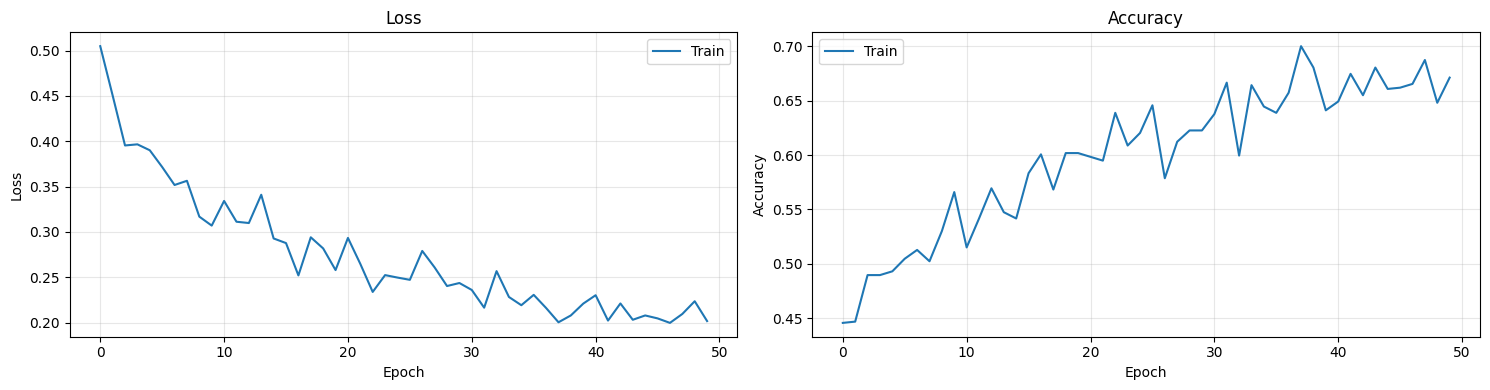

In [12]:
# PLOT TRAINING CURVES

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
# axes[0].plot(history["val_loss"], label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)



axes[1].plot(history["train_acc"], label="Train")
# axes[1].plot(history["val_acc"], label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig("onion/training_curves.png", dpi=150)
plt.show()

In [13]:

test_loss, test_seq = evaluate(model, intervention, test_loader, device, PAD_ID)
print(f"\nTest Results: loss={test_loss:.4f},  seq_acc={test_seq:.4f}")


Test Results: loss=0.2333,  seq_acc=0.6536


In [15]:
scale_params = intervention.scale_parameters()
for param_name, values in scale_params.items():
    print(f"{param_name}: mean={values.mean():.4f}, std={values.std():.4f}")

gamma: mean=0.8285, std=0.1081
lin: mean=-0.0984, std=0.0873
g: mean=1.0974, std=0.1278
b: mean=0.0513, std=0.1118


In [16]:

# Get detailed predictions
predictions_df = evaluate_with_predictions(model, intervention, test_loader, device, PAD_ID, id_to_phoneme)


wfe_df["No_Stress_str"] = wfe_df["No_Stress"].apply(lambda x: " ".join(x).strip())
predictions_df["input_no_eos"] = predictions_df["input"].apply(lambda x: x.replace("<EOS>", "").strip())

# merge with wfe_df 
merged_df = pd.merge(
    predictions_df,
    wfe_df.drop(columns=["Phonemes"]),
    left_on=['input_no_eos'],
    right_on=["No_Stress_str"],
    how="left"
)


merged_df = merged_df[["Word", "Condition","input", "target", "prediction", "position", "old_phoneme", "new_phoneme", "seq_len", "match", "token_acc",
                        "Lexicality", "Size", "Morphology", "Frequency", "Length", "Zipf_Frequency", "Part of Speech"]]
merged_df

,Word,Condition,input,target,prediction,position,old_phoneme,new_phoneme,seq_len,match,token_acc,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Part of Speech
0,towy,PSC,T OW IY <EOS>,T OW AO <EOS>,T OW AO <EOS>,2,IY,AO,4,True,1.000000,pseudo,short,complex,NaN,3,NaN,NaN
1,insane,RSCH,IH N S EY N <EOS>,IH N L EY N <EOS>,IH N L EY N <EOS>,2,S,L,6,True,1.000000,real,short,complex,2.510000e-05,5,4.40,ADJ
2,sallar,PSS,S AE L ER <EOS>,S JH L ER <EOS>,S JH L ER <EOS>,1,AE,JH,5,True,1.000000,pseudo,short,simple,NaN,4,NaN,NaN
3,get,RSSH,G EH T <EOS>,W EH T <EOS>,W EH T <EOS>,0,G,W,4,True,1.000000,real,short,simple,1.910000e-03,3,6.28,VERB
4,strugh,PSS,S T R UW <EOS>,S T R EH <EOS>,S T R EH <EOS>,3,UW,EH,5,True,1.000000,pseudo,short,simple,NaN,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,cajun,RSSL,K EY JH AH N <EOS>,K CH JH AH N <EOS>,K CH EY AH N <EOS>,1,EY,CH,6,False,0.833333,real,short,simple,9.770000e-07,5,2.99,PROPN
358,graduate,RLCH,G R AE JH AH W AH T <EOS>,G R AE JH AH OW AH T <EOS>,G R AE JH AH OW AH T <EOS>,5,W,OW,9,True,1.000000,real,long,complex,3.160000e-05,8,4.50,NOUN
359,bland,RSSL,B L AE N D <EOS>,B IH AE N D <EOS>,B AE AE N D <EOS>,1,L,IH,6,False,0.833333,real,short,simple,3.160000e-06,5,3.50,ADJ
360,shard,RSSL,SH AA R D <EOS>,SH D R D <EOS>,SH D R D <EOS>,1,AA,D,5,True,1.000000,real,short,simple,1.000000e-06,4,3.00,NOUN


In [ ]:
# er =merged_df[merged_df['match'] == False]
# long psudo words (accurate to paper)

# save er
# er.to_csv("onion/errors_no_intervention.csv", index=False)



In [103]:
def get_acc(path):
    df = pd.read_csv(path)
    return round(df['match'].mean(),4)

print("Accuracies:")
print(f"Onion Intervention (h and c): {get_acc('onion/predictions_h_c_one_probe.csv')}")
print(f"Onion Intervention (h only): {get_acc('onion/predictions_h_only_one_probe.csv')}")
print(f"Onion Intervention (c only): {get_acc('onion/predictions_c_only_one_probe.csv')}")

Accuracies:
Onion Intervention (h and c): 0.5994
Onion Intervention (h only): 0.0028
Onion Intervention (c only): 0.6796


In [ ]:
# merged_df.to_csv("onion/predictions_c_only_one_probe.csv", index=False)

In [138]:
df = pd.read_csv("onion/predictions_c_only_one_probe.csv")

In [ ]:
# comparision of different inout (real vs sudo)
df.groupby('Condition')['match'].mean().sort_values()
#category plot seaborn
# wich fsctor influance more on the accuracy

Condition
RLCL    0.400000
PLC     0.466667
RLSL    0.600000
RSCH    0.612903
RLSH    0.645161
PLS     0.666667
PSC     0.700000
RLCH    0.700000
RSSL    0.800000
PSS     0.833333
RSCL    0.833333
RSSH    0.900000
Name: match, dtype: float64

In [ ]:
#real/psudo long/short complex/simple low/high frequency

In [141]:
df.groupby('Lexicality')['match'].mean()

Lexicality
pseudo    0.666667
real      0.685950
Name: match, dtype: float64

In [148]:
df.groupby('Size')['match'].mean()

Size
long     0.580110
short    0.779006
Name: match, dtype: float64

In [147]:
df.groupby('position')['match'].mean()

position
0    0.809524
1    0.729730
2    0.690141
3    0.661017
4    0.558824
5    0.545455
6    0.608696
7    0.666667
8    0.400000
Name: match, dtype: float64

In [151]:
df['old_phoneme_type'] = df['old_phoneme'].apply(
    lambda x: phoneme_features[x]['Type'] if x in phoneme_features else pd.NA
)

df['new_phoneme_type'] = df['new_phoneme'].apply(
    lambda x: phoneme_features[x]['Type'] if x in phoneme_features else pd.NA
)

In [ ]:
df.groupby(['old_phoneme_type','new_phoneme_type'])['match'].mean()
# position and type 

old_phoneme_type  new_phoneme_type
C                 C                   0.800000
                  V                   0.549296
V                 C                   0.534884
                  V                   0.750000
Name: match, dtype: float64

In [158]:
df.groupby(['old_phoneme_type','new_phoneme_type'])['match'].count()

old_phoneme_type  new_phoneme_type
C                 C                   145
                  V                    71
V                 C                    86
                  V                    60
Name: match, dtype: int64

In [159]:
df[df["match"]==False].groupby(['old_phoneme_type','new_phoneme_type'])['match'].count()

old_phoneme_type  new_phoneme_type
C                 C                   29
                  V                   32
V                 C                   40
                  V                   15
Name: match, dtype: int64

In [161]:
df[(df["match"]==False) & (df["old_phoneme_type"]=='C') & (df["new_phoneme_type"]=='C')]

,Word,Condition,input,target,prediction,position,old_phoneme,new_phoneme,seq_len,match,token_acc,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Part of Speech,old_phoneme_type,new_phoneme_type
44,secrets,RLCH,S IY K R AH T S <EOS>,JH IY K R AH T S <EOS>,D IY JH R AH T S <EOS>,0,S,JH,8,False,0.750000,real,long,complex,2.040000e-05,7,4.31,NOUN,C,C
47,raspberries,RLCL,R AE Z B EH R IY Z <EOS>,R AE DH B EH R IY Z <EOS>,R AE B B EH R IY Z <EOS>,2,Z,DH,9,False,0.888889,real,long,complex,9.550000e-07,8,2.98,NOUN,C,C
49,duplex,RLCL,D UW P L EH K S <EOS>,D UW R L EH K S <EOS>,D R R L EH K S <EOS>,2,P,R,8,False,0.875000,real,long,complex,1.350000e-06,7,3.13,NOUN,C,C
57,opist,PSC,OW P IH S T <EOS>,OW P IH S N <EOS>,OW P IH N N <EOS>,4,T,N,6,False,0.833333,pseudo,short,complex,NaN,5,NaN,NaN,C,C
60,aorta,RSSL,EY AO R T AH <EOS>,EY AO Z T AH <EOS>,EY AO Z AH AH <EOS>,2,R,Z,6,False,0.833333,real,short,simple,8.320000e-07,5,2.92,PROPN,C,C
66,trynkabel,PLS,T R IH N K AH B EH L <EOS>,T R IH N JH AH B EH L <EOS>,T R IH N JH EH B EH L <EOS>,4,K,JH,10,False,0.900000,pseudo,long,simple,NaN,9,NaN,NaN,C,C
72,uniforist,PLC,Y UW N AH F AO R S T <EOS>,Y UW N AH F AO R S Y <EOS>,F UW F AH F AO R S Y <EOS>,8,T,Y,10,False,0.800000,pseudo,long,complex,NaN,9,NaN,NaN,C,C
102,vulgarist,PLC,V AH L G ER IH S T <EOS>,V AH L NG ER IH S T <EOS>,V AH L S ER IH S L <EOS>,3,G,NG,9,False,0.777778,pseudo,long,complex,NaN,8,NaN,NaN,C,C
121,property,RLCH,P R AA P ER T IY <EOS>,P Z AA P ER T IY <EOS>,P AA AA P ER T IY <EOS>,1,R,Z,8,False,0.875000,real,long,complex,1.290000e-04,7,5.11,NOUN,C,C
122,register,RLSH,R EH JH IH S T ER <EOS>,R EH JH IH W T ER <EOS>,R EH JH IH T T ER <EOS>,4,S,W,8,False,0.875000,real,long,simple,3.890000e-05,7,4.59,VERB,C,C


In [163]:
df.loc[72]

Word                                 uniforist
Condition                                  PLC
input               Y UW N AH F AO R S T <EOS>
target              Y UW N AH F AO R S Y <EOS>
prediction          F UW F AH F AO R S Y <EOS>
position                                     8
old_phoneme                                  T
new_phoneme                                  Y
seq_len                                     10
match                                    False
token_acc                                  0.8
Lexicality                              pseudo
Size                                      long
Morphology                             complex
Frequency                                  NaN
Length                                       9
Zipf_Frequency                             NaN
Part of Speech                             NaN
old_phoneme_type                             C
new_phoneme_type                             C
Name: 72, dtype: object

In [19]:
merged_df.sort_values(by='token_acc').head(10)


,Word,Condition,input,target,prediction,position,old_phoneme,new_phoneme,seq_len,match,token_acc,Lexicality,Size,Morphology,Frequency,Length,Zipf_Frequency,Part of Speech
308,authored,RSCL,AO TH ER D <EOS>,AO TH ER OY <EOS>,AO OY OY OY <EOS>,3,D,OY,5,False,0.600000,real,short,complex,3.090000e-06,4,3.49,VERB
286,teetin,PSC,T IY T IH N <EOS>,T IY T IH AY <EOS>,T IY AY AY AY <EOS>,4,N,AY,6,False,0.666667,pseudo,short,complex,NaN,5,NaN,NaN
203,update,RSCH,AH P D EY T <EOS>,AH P D B T <EOS>,AH B B B T <EOS>,3,EY,B,6,False,0.666667,real,short,complex,4.900000e-05,5,4.69,VERB
293,percentage,RLCH,P ER S EH N T AH JH <EOS>,P ER S DH N T AH JH <EOS>,P ER S P T AH AH JH <EOS>,3,EH,DH,9,False,0.666667,real,long,complex,3.020000e-05,8,4.48,NOUN
200,cladwicheet,PLS,K L AE D W IH CH IY T <EOS>,K L AE D W IH CH IY DH <EOS>,K L AE D W AO AO ER DH <EOS>,8,T,DH,10,False,0.700000,pseudo,long,simple,NaN,9,NaN,NaN
157,islaterdine,PLS,IH S L AA T ER D AY N <EOS>,IH S L AA T ER ZH AY N <EOS>,IH S L AA T ZH ZH EH <EOS> <EOS>,6,D,ZH,10,False,0.700000,pseudo,long,simple,NaN,9,NaN,NaN
100,aladquary,PLC,AE L AH D K W AO R EY <EOS>,AE IY AH D K W AO R EY <EOS>,AE IY AH D AO EY AO R IY <EOS>,1,L,IY,10,False,0.700000,pseudo,long,complex,NaN,9,NaN,NaN
304,sculptural,RLCL,S K AH L P CH ER AH L <EOS>,S K DH L P CH ER AH L <EOS>,S K L L CH CH ER DH L <EOS>,2,AH,DH,10,False,0.700000,real,long,complex,7.940000e-07,9,2.90,ADJ
284,solocomov,PLS,S OW L OW K AH M AO F <EOS>,S OW L OW K AH M TH F <EOS>,S OW L OW M M M TH <EOS> <EOS>,7,AO,TH,10,False,0.700000,pseudo,long,simple,NaN,9,NaN,NaN
23,known,RSCH,N OW N <EOS>,HH OW N <EOS>,HH OW HH <EOS>,0,N,HH,4,False,0.750000,real,short,complex,2.450000e-04,3,5.39,VERB


In [167]:
df.groupby('old_phoneme')['match'].mean().sort_values(ascending=True).head(10)

old_phoneme
DH    0.000000
OW    0.200000
Z     0.250000
EY    0.428571
W     0.500000
AH    0.500000
SH    0.500000
M     0.500000
D     0.500000
K     0.529412
Name: match, dtype: float64

In [168]:
df.groupby('new_phoneme')['match'].mean().sort_values(ascending=True).head(10)

new_phoneme
DH    0.100000
AE    0.363636
R     0.375000
W     0.444444
AW    0.500000
AY    0.500000
V     0.500000
HH    0.500000
AO    0.615385
OY    0.625000
Name: match, dtype: float64

In [ ]:
# hypothesis: hihger error  with negative SSP

